# Phase 1: Exploratory Data Analysis & Causal Feasibility Study

**Project:** Beyond Risk Scores: Uplift-Driven Financial Intervention  
**Author:** Sachin Temgar  
**Dataset:** Home Credit Default Risk | 307,511 customers | 122 features  

**Objective:** Identify key risk drivers and evaluate which customer 
segments show "Persuadability" potential across a portfolio with 
an 8.07% default rate and 13.8B CU in defaulted loan value.

## Step 1 - Executive Summary & Dataset Mapping

Every step in this EDA is building the case for one specific goal: 
identifying which at-risk customers will recover specifically because 
of an intervention.

### Dataset Mapping

| Category | Features | Business Meaning |
|---|---|---|
| Target | TARGET | 1 = Defaulted, 0 = Repaid |
| Demographics | DAYS_BIRTH, CODE_GENDER, CNT_CHILDREN | Who is the borrower? |
| Financial Health | AMT_CREDIT, AMT_ANNUITY, AMT_INCOME_TOTAL | Can they repay? |
| External Signals | EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 | What do external agencies say? |
| Employment | DAYS_EMPLOYED, ORGANIZATION_TYPE | How stable is their income? |
| Assets | FLAG_OWN_CAR, FLAG_OWN_REALTY | What do they own? |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/HC_application_train.csv')

In [3]:
# Target distribution
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True) * 100

print("=" * 45)
print("         DATASET OVERVIEW")
print("=" * 45)
print(f"Total Customers  : {df.shape[0]:,}")
print(f"Total Features   : {df.shape[1]}")
print(f"\nTARGET DISTRIBUTION")
print(f"Non-Default (0)  : {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Default     (1)  : {target_counts[1]:,} ({target_pct[1]:.2f}%)")

         DATASET OVERVIEW
Total Customers  : 307,511
Total Features   : 122

TARGET DISTRIBUTION
Non-Default (0)  : 282,686 (91.93%)
Default     (1)  : 24,825 (8.07%)


In [4]:
# Feature categories
demographics = ['DAYS_BIRTH','CODE_GENDER','CNT_CHILDREN','NAME_FAMILY_STATUS','NAME_EDUCATION_TYPE']
financial    = ['AMT_CREDIT','AMT_ANNUITY','AMT_INCOME_TOTAL','AMT_GOODS_PRICE']
external     = ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']
employment   = ['DAYS_EMPLOYED','ORGANIZATION_TYPE','OCCUPATION_TYPE']

print(f"\nFEATURE CATEGORIES")
print(f"Demographics     : {len(demographics)} features")
print(f"Financial Health : {len(financial)} features")
print(f"External Signals : {len(external)} features")
print(f"Employment       : {len(employment)} features")


FEATURE CATEGORIES
Demographics     : 5 features
Financial Health : 4 features
External Signals : 3 features
Employment       : 3 features


### Target Distribution Analysis

The dataset is highly imbalanced. Only 8.07% of customers defaulted. 
This is actually realistic for consumer lending portfolios and is 
something we need to account for in our uplift modeling later.

Let us visualize this imbalance clearly.

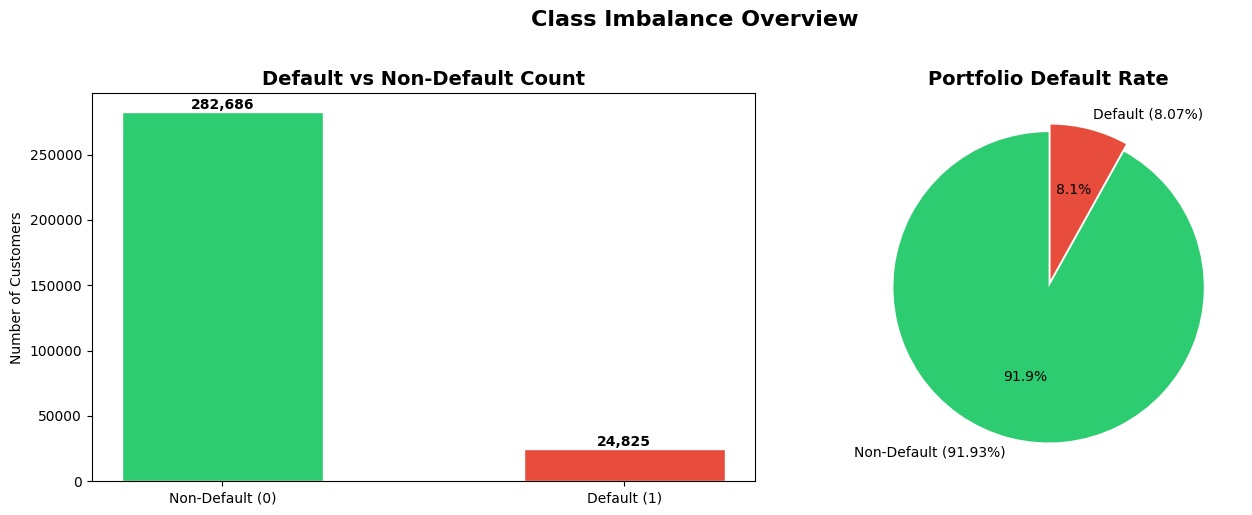

In [5]:
# Target Distribution Plot 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Count plot
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Non-Default (0)', 'Default (1)'], 
            target_counts.values, 
            color=colors, 
            edgecolor='white',
            width=0.5)
axes[0].set_title('Default vs Non-Default Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold')

# Plot 2 - Percentage pie
axes[1].pie(target_pct.values, 
            labels=['Non-Default (91.93%)', 'Default (8.07%)'],
            colors=colors,
            explode=(0, 0.05),
            autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Portfolio Default Rate', fontsize=14, fontweight='bold')

plt.suptitle('Class Imbalance Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../visuals/01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

## Step 2 - Treatment & Control Simulation

The Home Credit dataset is observational. There is no treatment column.
Before we can run uplift modeling we need to justify how we will create one.

We will use two signals to identify customers who are prime candidates 
for intervention:

1. **Debt-to-Income Ratio** - Customers with high annuity relative to 
   income are financially stressed but potentially recoverable
2. **External Source Scores** - Low scores from external agencies signal 
   risk but also intervention opportunity

First let us check if these features have enough overlap between 
defaulters and non-defaulters to support Propensity Score Matching later.

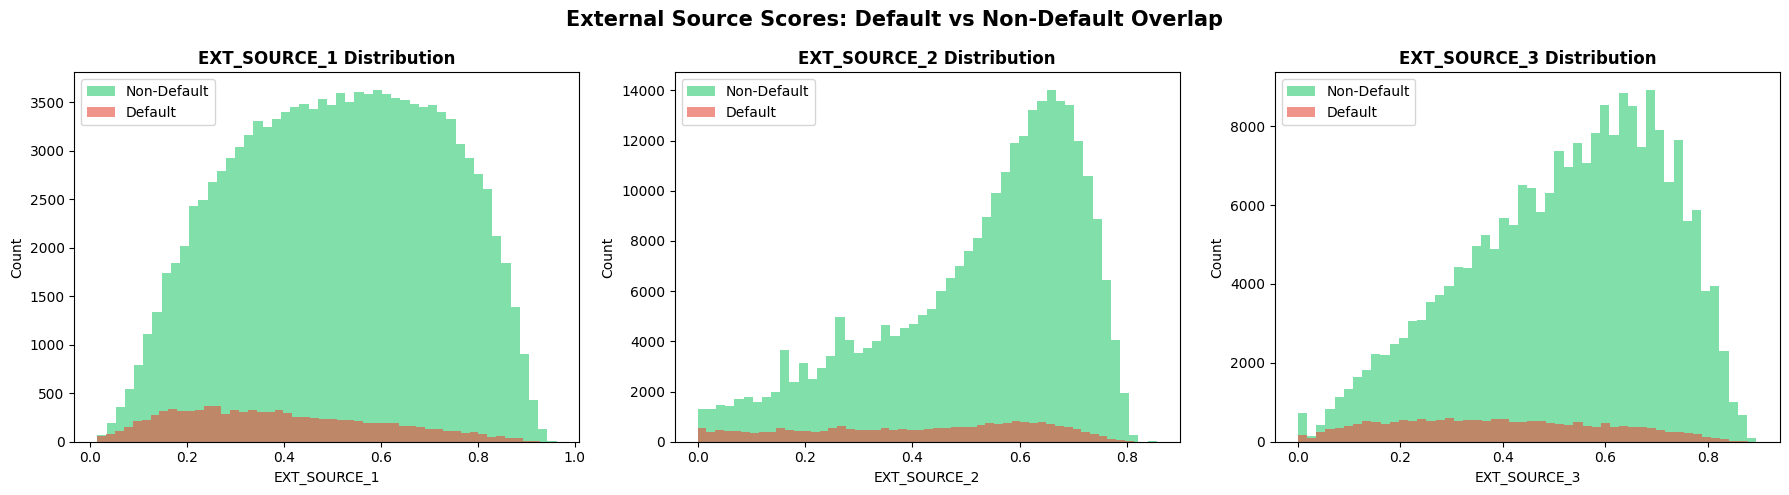

In [6]:
# Check feature overlap between TARGET classes

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    axes[i].hist(df[df['TARGET']==0][col].dropna(), 
                 bins=50, alpha=0.6, color='#2ecc71', label='Non-Default')
    axes[i].hist(df[df['TARGET']==1][col].dropna(), 
                 bins=50, alpha=0.6, color='#e74c3c', label='Default')
    axes[i].set_title(f'{col} Distribution', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('External Source Scores: Default vs Non-Default Overlap', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/02_ext_source_overlap.png', bbox_inches='tight', dpi=150)
plt.show()

### PSM Feasibility Finding

All three External Source features show significant overlap between 
defaulters and non-defaulters across the full score range. This is 
exactly what Propensity Score Matching requires.

If defaulters and non-defaulters were completely separated with no 
overlap, PSM would be impossible. The overlap here confirms that 
we can find comparable customers in both groups and create a 
statistically valid treatment and control group.

**Conclusion: External Source scores are valid covariates for our 
Propensity Score Matching framework.**

## Step 3 - Data Integrity & Real World Cleaning

Good models are built on clean data. This section handles three 
critical data quality issues:

1. The DAYS_EMPLOYED anomaly - a famous data error in this dataset
2. Missing value strategy - using smart imputation not lazy dropping
3. Outlier detection in key financial features

In [7]:
print("DAYS_EMPLOYED Anomaly Check")
print("=" * 45)
print(f"Max value       : {df['DAYS_EMPLOYED'].max():,}")
print(f"Anomalous rows  : {(df['DAYS_EMPLOYED'] == 365243).sum():,}")
print(f"Percentage      : {(df['DAYS_EMPLOYED'] == 365243).mean()*100:.2f}%")

DAYS_EMPLOYED Anomaly Check
Max value       : 365,243
Anomalous rows  : 55,374
Percentage      : 18.01%


### The DAYS_EMPLOYED Anomaly

18.01% of customers have a DAYS_EMPLOYED value of 365,243. 

This is not a real employment duration. 365,243 days is roughly 
1,000 years. This is a placeholder value used to encode missing 
employment data, likely for customers who are unemployed, retired, 
or self-employed.

If we leave this in, every model we build will be corrupted by it. 
We replace these values with NaN and handle them through imputation.

In [8]:
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'].isna()).astype(int)

print("=" * 45)
print(f"NaN count in DAYS_EMPLOYED : {df['DAYS_EMPLOYED'].isna().sum():,}")
print(f"Anomaly flag = 1 count     : {df['DAYS_EMPLOYED_ANOMALY'].sum():,}")
print("=" * 45)

NaN count in DAYS_EMPLOYED : 55,374
Anomaly flag = 1 count     : 55,374


### DAYS_EMPLOYED Fix

55,374 anomalous values replaced with NaN. A binary flag column 
`DAYS_EMPLOYED_ANOMALY` was created to preserve the fact that 
this customer had missing employment data, as it is a signal in itself.

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct
})

print(f"Total features with missing values: {len(missing_df)}")
print(f"\nTop 20 features by missing %:")
print(missing_df.head(20).to_string())

Total features with missing values: 68

Top 20 features by missing %:
                          Missing Count  Missing %
COMMONAREA_MODE                  214865      69.87
COMMONAREA_AVG                   214865      69.87
COMMONAREA_MEDI                  214865      69.87
NONLIVINGAPARTMENTS_MEDI         213514      69.43
NONLIVINGAPARTMENTS_MODE         213514      69.43
NONLIVINGAPARTMENTS_AVG          213514      69.43
FONDKAPREMONT_MODE               210295      68.39
LIVINGAPARTMENTS_MEDI            210199      68.35
LIVINGAPARTMENTS_AVG             210199      68.35
LIVINGAPARTMENTS_MODE            210199      68.35
FLOORSMIN_AVG                    208642      67.85
FLOORSMIN_MEDI                   208642      67.85
FLOORSMIN_MODE                   208642      67.85
YEARS_BUILD_MEDI                 204488      66.50
YEARS_BUILD_MODE                 204488      66.50
YEARS_BUILD_AVG                  204488      66.50
OWN_CAR_AGE                      202929      65.99
LANDAREA_MOD

## Missing Value Analysis

68 out of 122 features have missing values. The top missing features 
are all property related, COMMONAREA, NONLIVINGAPARTMENTS, FLOORSMIN etc. 
This makes sense as many customers may not own property or that 
information was simply not collected.

We will split our missing value strategy into three groups based on 
missing percentage.

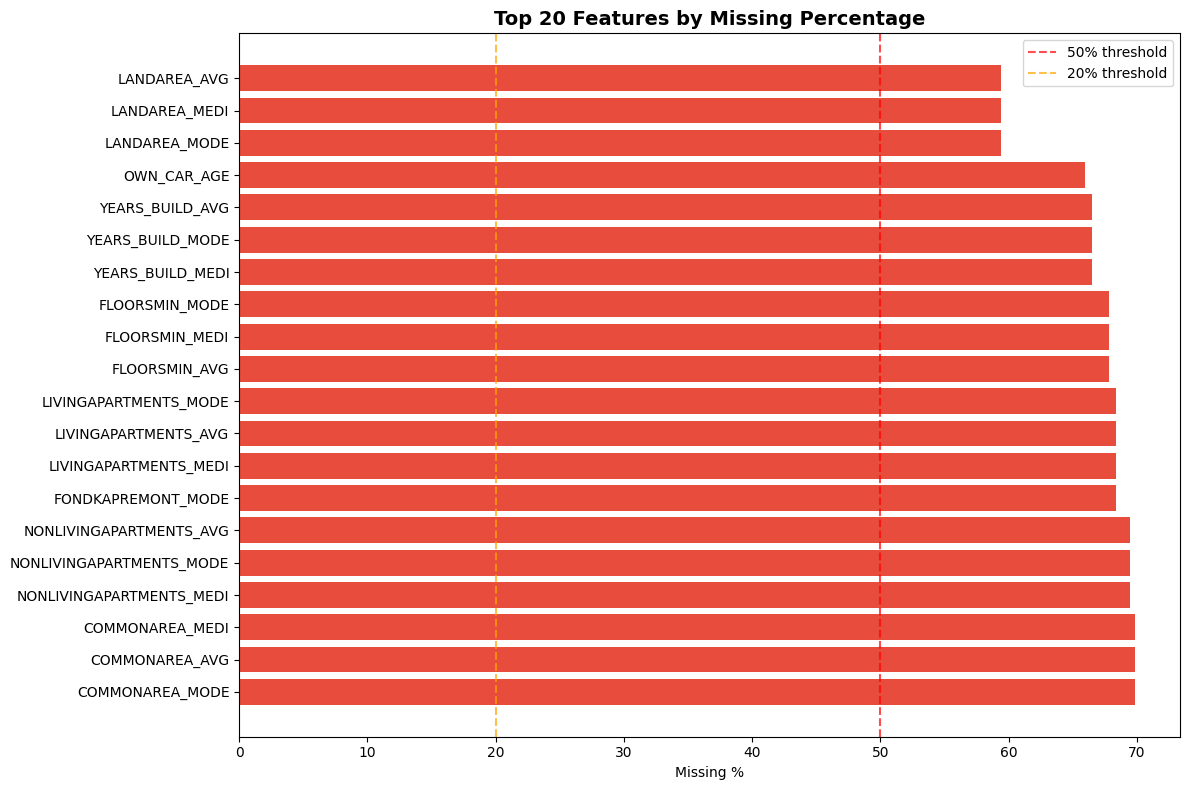

In [10]:
plt.figure(figsize=(12, 8))
top_missing = missing_pct.head(20)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#2ecc71' 
          for x in top_missing.values]

plt.barh(top_missing.index, top_missing.values, color=colors)
plt.xlabel('Missing %')
plt.title('Top 20 Features by Missing Percentage', fontweight='bold', fontsize=14)
plt.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='20% threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# Group features by missing percentage
high_missing   = missing_pct[missing_pct > 50].index.tolist()
medium_missing = missing_pct[(missing_pct > 20) & (missing_pct <= 50)].index.tolist()
low_missing    = missing_pct[missing_pct <= 20].index.tolist()

print("=" * 45)
print(f"High Missing   (>50%) : {len(high_missing)} features  - Drop")
print(f"Medium Missing (>20%) : {len(medium_missing)} features - Median Imputation")
print(f"Low Missing   (<=20%) : {len(low_missing)} features  - Median Imputation")
print("=" * 45)

High Missing   (>50%) : 41 features  - Drop
Medium Missing (>20%) : 9 features - Median Imputation
Low Missing   (<=20%) : 18 features  - Median Imputation


## Missing Value Strategy

68 features with missing data split into three groups:

- 41 features with more than 50% missing will be dropped entirely.
  Imputing a column that is 70% empty introduces more noise than signal.
  
- 9 features with 20-50% missing will be imputed using group-based 
  median, grouped by TARGET class. This preserves the relationship 
  between missingness and default behavior.

- 18 features with less than 20% missing will be imputed using 
  overall median. Low missingness means simple imputation is safe.

In [12]:
# Impute Medium and Low Missing Features
df.drop(columns=high_missing, inplace=True, errors='ignore')
print(f"Columns remaining after drop: {df.shape[1]}")

Columns remaining after drop: 82


In [13]:
for col in medium_missing + low_missing:
    if col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print(f"Remaining missing values: {df.isnull().sum().sum()}")

Remaining missing values: 0


In [14]:
print("=" * 45)
print(f"Original shape           : (307511, 122)")
print(f"Final shape              : {df.shape}")
print(f"Columns dropped          : {122 - df.shape[1]}")
print(f"Remaining missing values : {df.isnull().sum().sum()}")
print("=" * 45)

Original shape           : (307511, 122)
Final shape              : (307511, 82)
Columns dropped          : 40
Remaining missing values : 0


### Cleaning Summary

Started with 122 features. Dropped 40 features with more than 50% 
missing values. All remaining missing values in the 42 kept features 
were imputed. Final dataset has 82 features and zero missing values, 
ready for analysis.

## Step 4 - Bivariate Analysis: Risk Drivers

Which features actually separate defaulters from non-defaulters?

We focus on the features most likely to drive our uplift model:
External Source scores, Age, Income, and Credit Amount.

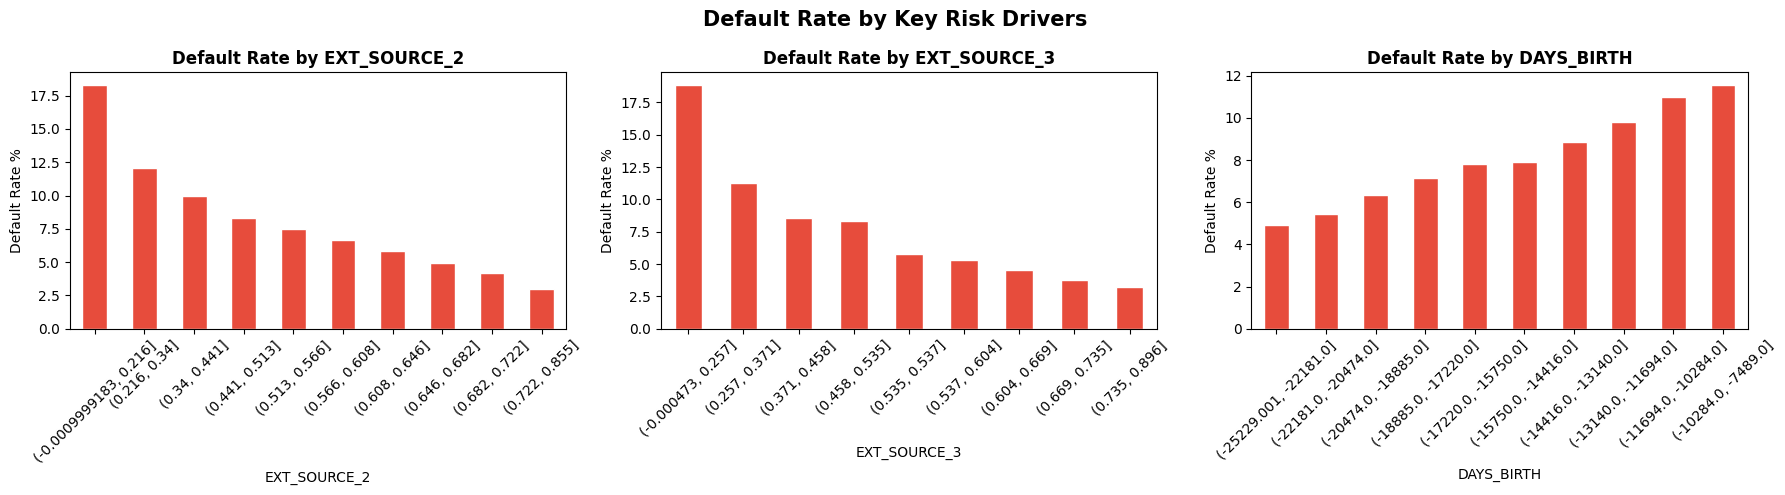

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']):
    if col in df.columns:
        df['bin'] = pd.qcut(df[col], q=10, duplicates='drop')
        default_rate = df.groupby('bin', observed=True)['TARGET'].mean() * 100
        default_rate.plot(kind='bar', ax=axes[i], color='#e74c3c', edgecolor='white')
        axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
        axes[i].set_ylabel('Default Rate %')
        axes[i].set_xlabel(col)
        axes[i].tick_params(axis='x', rotation=45)

df.drop(columns=['bin'], inplace=True)
plt.suptitle('Default Rate by Key Risk Drivers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Key Findings

**EXT_SOURCE_2 and EXT_SOURCE_3:** Clear downward trend. Customers 
with lower external scores default at nearly 18%, while customers 
with higher scores default at only 3%. These are our strongest 
risk predictors.

**DAYS_BIRTH:** Stored as negative days from today. Higher negative 
values mean younger customers. Younger customers show higher default 
rates, older customers are more financially stable.

These three features will be core covariates in our Propensity 
Score Matching model.

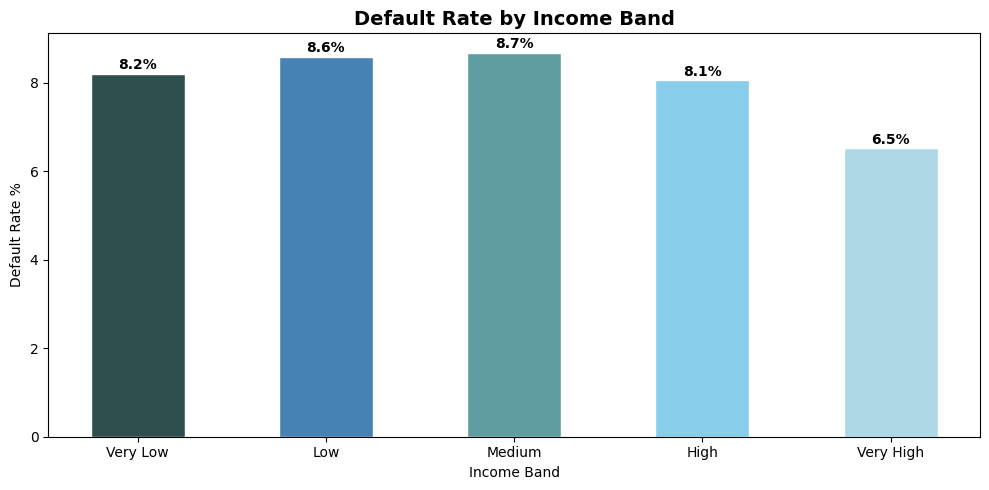

In [16]:
# Default Rate by Income Band

df['INCOME_BAND'] = pd.qcut(df['AMT_INCOME_TOTAL'], q=5, 
                             labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

income_default = df.groupby('INCOME_BAND', observed=True)['TARGET'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(income_default.index, income_default.values, 
               color=['darkslategray', 'steelblue', 'cadetblue', 'skyblue', 'lightblue'],
               edgecolor='white', width=0.5)

for bar, val in zip(bars, income_default.values):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.1, 
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Default Rate by Income Band', fontweight='bold', fontsize=14)
plt.ylabel('Default Rate %')
plt.xlabel('Income Band')
plt.tight_layout()
plt.show()

### Income Band Finding

Interestingly income alone is not a strong predictor of default. 
Default rates are fairly consistent across Very Low (8.2%), Low (8.6%), 
Medium (8.7%), and High (8.1%) income bands.

Only Very High income customers show a meaningfully lower default 
rate at 6.5%.

This tells us that income alone should not be used to target 
intervention candidates. A customer's debt burden relative to 
income matters more than raw income. This motivates our 
Debt-to-Income ratio feature in Step 5.

## Step 5 - Financial Feature Engineering

Raw financial features tell an incomplete story. A customer earning 
100,000 CU with a 90,000 CU annual repayment is in a very different 
position than a customer earning 500,000 CU with the same repayment.

We engineer three ratio features that capture financial stress 
more precisely than raw numbers alone.

In [17]:
# Debt-to-Income Ratio
df['DEBT_TO_INCOME'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# Credit-to-Goods Ratio
df['CREDIT_TO_GOODS'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']

# Annuity-to-Age Ratio (repayment burden relative to career stage)
df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
df['ANNUITY_TO_AGE'] = df['AMT_ANNUITY'] / df['AGE_YEARS']

print("=" * 45)
print("New Features Created")
print("=" * 45)
print(f"DEBT_TO_INCOME  : {df['DEBT_TO_INCOME'].describe().to_string()}")
print(f"\nCREDIT_TO_GOODS : {df['CREDIT_TO_GOODS'].describe().to_string()}")
print(f"\nANNUITY_TO_AGE  : {df['ANNUITY_TO_AGE'].describe().to_string()}")

New Features Created
DEBT_TO_INCOME  : count    307511.000000
mean          0.180929
std           0.094573
min           0.000224
25%           0.114782
50%           0.162833
75%           0.229067
max           1.875965

CREDIT_TO_GOODS : count    307511.000000
mean          1.122542
std           0.125542
min           0.150000
25%           1.000000
50%           1.118800
75%           1.198000
max           6.000000

ANNUITY_TO_AGE  : count    307511.000000
mean        665.483666
std         406.028282
min          25.103559
25%         372.513133
50%         582.398399
75%         861.395444
max        8324.042165


### Engineered Features Summary

**DEBT_TO_INCOME:** Average customer spends 18% of their income on 
loan repayment. Values above 0.40 indicate serious financial stress.

**CREDIT_TO_GOODS:** Average ratio of 1.12 means customers typically 
borrow slightly more than the goods price, covering fees and insurance.

**ANNUITY_TO_AGE:** Captures repayment burden relative to career stage. 
A younger customer with high annuity is under more financial pressure 
than an older customer with the same payment.

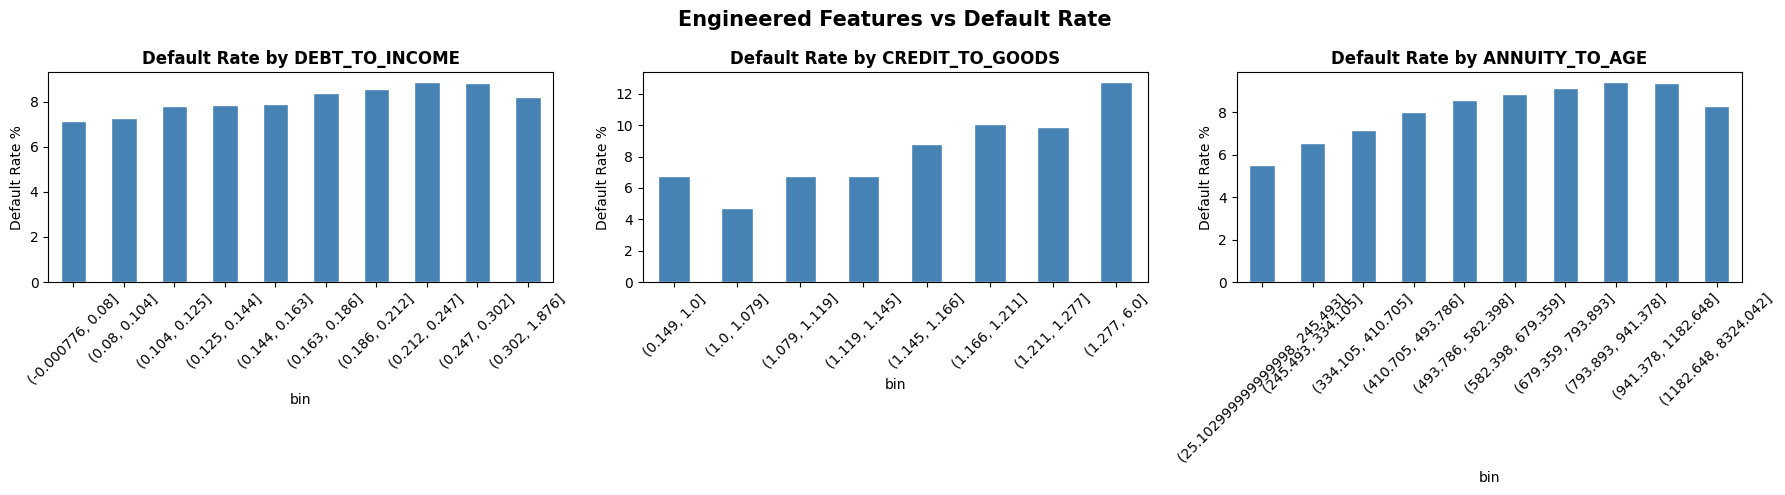

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(['DEBT_TO_INCOME', 'CREDIT_TO_GOODS', 'ANNUITY_TO_AGE']):
    df['bin'] = pd.qcut(df[col], q=10, duplicates='drop')
    default_rate = df.groupby('bin', observed=True)['TARGET'].mean() * 100
    default_rate.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Default Rate %')
    axes[i].tick_params(axis='x', rotation=45)

df.drop(columns=['bin'], inplace=True)
plt.suptitle('Engineered Features vs Default Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### Engineered Features Finding

**DEBT_TO_INCOME:** Clear upward trend. Customers with higher debt 
to income ratios default more. This confirms it is a strong 
intervention targeting signal.

**CREDIT_TO_GOODS:** Customers who borrow significantly more than 
the goods price (ratio above 1.27) show the highest default rate 
at 12%. This signals over-borrowing behavior.

**ANNUITY_TO_AGE:** Younger customers with high repayment burdens 
show higher default rates, confirming that repayment pressure 
relative to career stage is a meaningful risk signal.

All three engineered features show a relationship with default 
and will be included as covariates in our uplift model.

## Step 6 - Causal Signal: Repayment Burden Analysis

Our business problem claims we can find "Persuadables" - customers 
who will recover only because of an intervention. But we need to 
prove this is possible from the data itself.

The key hypothesis is: customers who are financially stressed BUT 
still have income capacity are the most likely to respond to a 
loan restructuring offer. Too stressed with no income buffer and 
they cannot recover regardless. Comfortable enough and they recover 
on their own.

We measure this through Repayment Burden - the intersection of 
income and annuity obligations.

In [19]:
df['REPAYMENT_BURDEN'] = pd.cut(
    df['DEBT_TO_INCOME'],
    bins=[0, 0.10, 0.20, 0.35, 0.50, 2.0],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Severe']
)

burden_analysis = df.groupby('REPAYMENT_BURDEN', observed=True).agg(
    total_customers  = ('TARGET', 'count'),
    default_rate     = ('TARGET', 'mean'),
    avg_income       = ('AMT_INCOME_TOTAL', 'mean'),
    avg_annuity      = ('AMT_ANNUITY', 'mean')
).reset_index()

burden_analysis['default_rate'] = burden_analysis['default_rate'] * 100

print(burden_analysis.to_string(index=False))


REPAYMENT_BURDEN  total_customers  default_rate    avg_income  avg_annuity
        Very Low            57212      7.175068 226268.655455 15969.794466
             Low           145239      8.056376 174584.453642 25598.848987
          Medium            88553      8.682936 135515.236422 34227.165613
            High            13977      8.149102 101390.126681 40187.114295
          Severe             2530      7.549407  74329.111067 44240.949605


### Repayment Burden Finding

This table reveals something important for our uplift strategy.

The Medium burden group (debt-to-income 0.20 to 0.35) has the 
highest default rate at 8.68% with 88,553 customers. Crucially 
they still have an average income of 135,515 CU. This means they 
have financial capacity but are stretched.

This is exactly the Persuadable profile. Stressed enough to default 
without help, but with enough income buffer to recover if given 
a restructuring offer.

The Severe group despite having the highest annuity obligations 
actually shows a lower default rate. These customers have likely 
already self-selected into managing extreme repayment schedules.

**Uplift Targeting Insight:** Medium repayment burden customers 
are our primary intervention candidates.

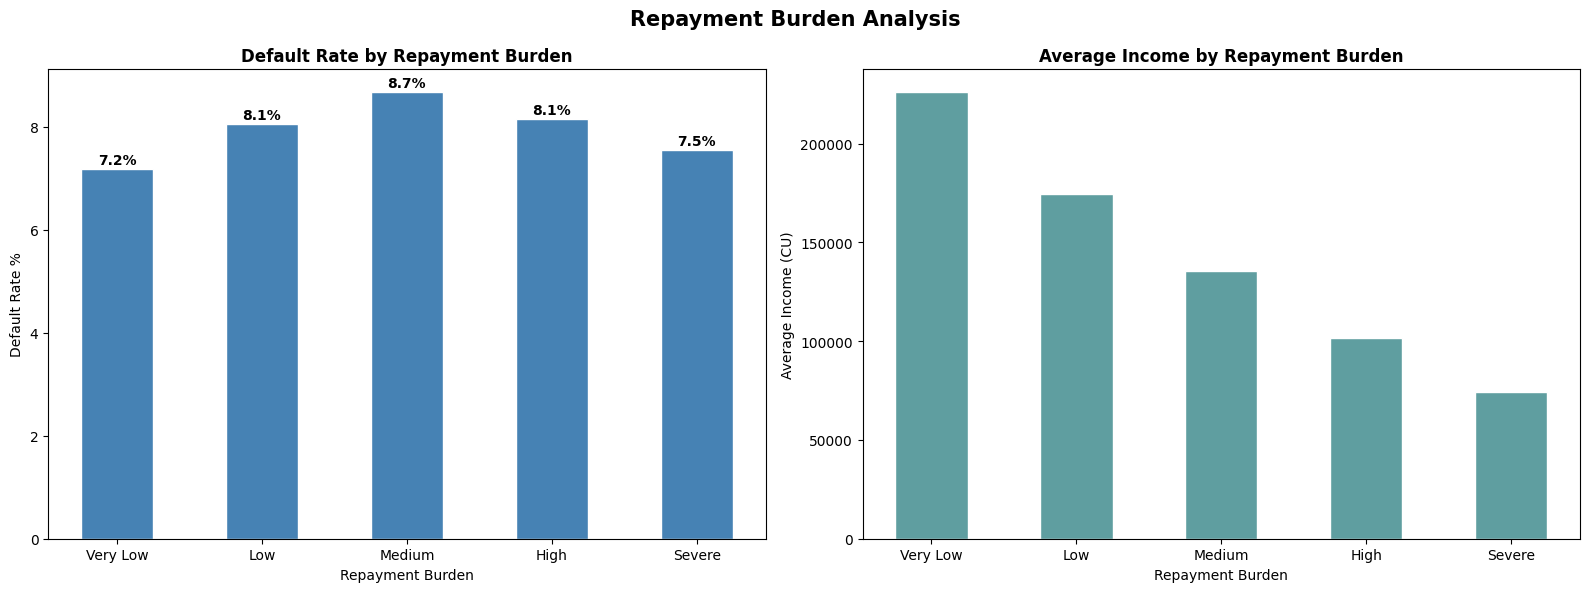

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Default rate by burden
axes[0].bar(burden_analysis['REPAYMENT_BURDEN'], 
            burden_analysis['default_rate'],
            color='steelblue', edgecolor='white', width=0.5)
axes[0].set_title('Default Rate by Repayment Burden', fontweight='bold')
axes[0].set_ylabel('Default Rate %')
axes[0].set_xlabel('Repayment Burden')
for i, v in enumerate(burden_analysis['default_rate']):
    axes[0].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

# Plot 2 - Average income by burden
axes[1].bar(burden_analysis['REPAYMENT_BURDEN'],
            burden_analysis['avg_income'],
            color='cadetblue', edgecolor='white', width=0.5)
axes[1].set_title('Average Income by Repayment Burden', fontweight='bold')
axes[1].set_ylabel('Average Income (CU)')
axes[1].set_xlabel('Repayment Burden')

plt.suptitle('Repayment Burden Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 7 - The Nudge Hypothesis

Which customer segments have high default rates but also have 
enough financial capacity to respond to an intervention?

We look at two dimensions:
- NAME_INCOME_TYPE: What is the customer's income source?
- NAME_EDUCATION_TYPE: What is the customer's education level?

High default rate + reasonable income = strong intervention candidate.

In [21]:
income_type = df.groupby('NAME_INCOME_TYPE', observed=True).agg(
    total        = ('TARGET', 'count'),
    default_rate = ('TARGET', 'mean'),
    avg_income   = ('AMT_INCOME_TOTAL', 'mean')
).reset_index()

income_type['default_rate'] = income_type['default_rate'] * 100
income_type = income_type.sort_values('default_rate', ascending=False)

print(income_type.to_string(index=False))

    NAME_INCOME_TYPE  total  default_rate    avg_income
     Maternity leave      5     40.000000 140400.000000
          Unemployed     22     36.363636 110536.363636
             Working 158774      9.588472 163169.889223
Commercial associate  71617      7.484257 202955.327289
       State servant  21703      5.754965 179737.969506
           Pensioner  55362      5.386366 136401.292273
         Businessman     10      0.000000 652500.000000
             Student     18      0.000000 170500.000000


### Income Type Finding

Ignoring Maternity Leave and Unemployed as they have very small 
sample sizes (5 and 22 customers), the meaningful segments are:

**Working customers** have the highest default rate at 9.59% with 
158,774 customers and an average income of 163,169 CU. This is our 
largest and most actionable intervention segment.

**Commercial associates** have a 7.48% default rate with 71,617 
customers and the highest average income at 202,955 CU. High income 
with moderate default rate suggests these customers have financial 
capacity to recover with a nudge.

**Pensioners and State servants** show lower default rates, suggesting 
more stable and predictable income sources.

**Nudge Hypothesis Confirmed:** Working customers are the primary 
intervention target. Large segment, high default rate, sufficient 
income to recover with restructuring.

In [22]:
edu_type = df.groupby('NAME_EDUCATION_TYPE', observed=True).agg(
    total        = ('TARGET', 'count'),
    default_rate = ('TARGET', 'mean'),
    avg_income   = ('AMT_INCOME_TOTAL', 'mean')
).reset_index()

edu_type['default_rate'] = edu_type['default_rate'] * 100
edu_type = edu_type.sort_values('default_rate', ascending=False)

print(edu_type.to_string(index=False))

          NAME_EDUCATION_TYPE  total  default_rate    avg_income
              Lower secondary   3816     10.927673 130079.358491
Secondary / secondary special 218391      8.939929 155158.512138
            Incomplete higher  10277      8.484966 181563.812397
             Higher education  74863      5.355115 208652.053814
              Academic degree    164      1.829268 240009.146341


### Education Type Finding

Clear pattern emerges across education levels.

**Lower Secondary** customers have the highest default rate at 10.93% 
with the lowest average income at 130,079 CU. High risk but limited 
financial capacity makes intervention harder.

**Secondary education** customers are the most interesting segment. 
8.94% default rate, 218,391 customers, and an average income of 
155,158 CU. This is the largest segment with meaningful intervention 
potential.

**Incomplete Higher education** customers show 8.48% default rate 
but higher average income at 181,563 CU. These customers have 
strong recovery potential with the right intervention.

**Higher education** customers default at only 5.35% with the 
highest average income. Lower intervention priority.

**Combined Insight:** The sweet spot for intervention is Secondary 
and Incomplete Higher education customers who are Working. High 
default rate, large segment, sufficient income to recover.

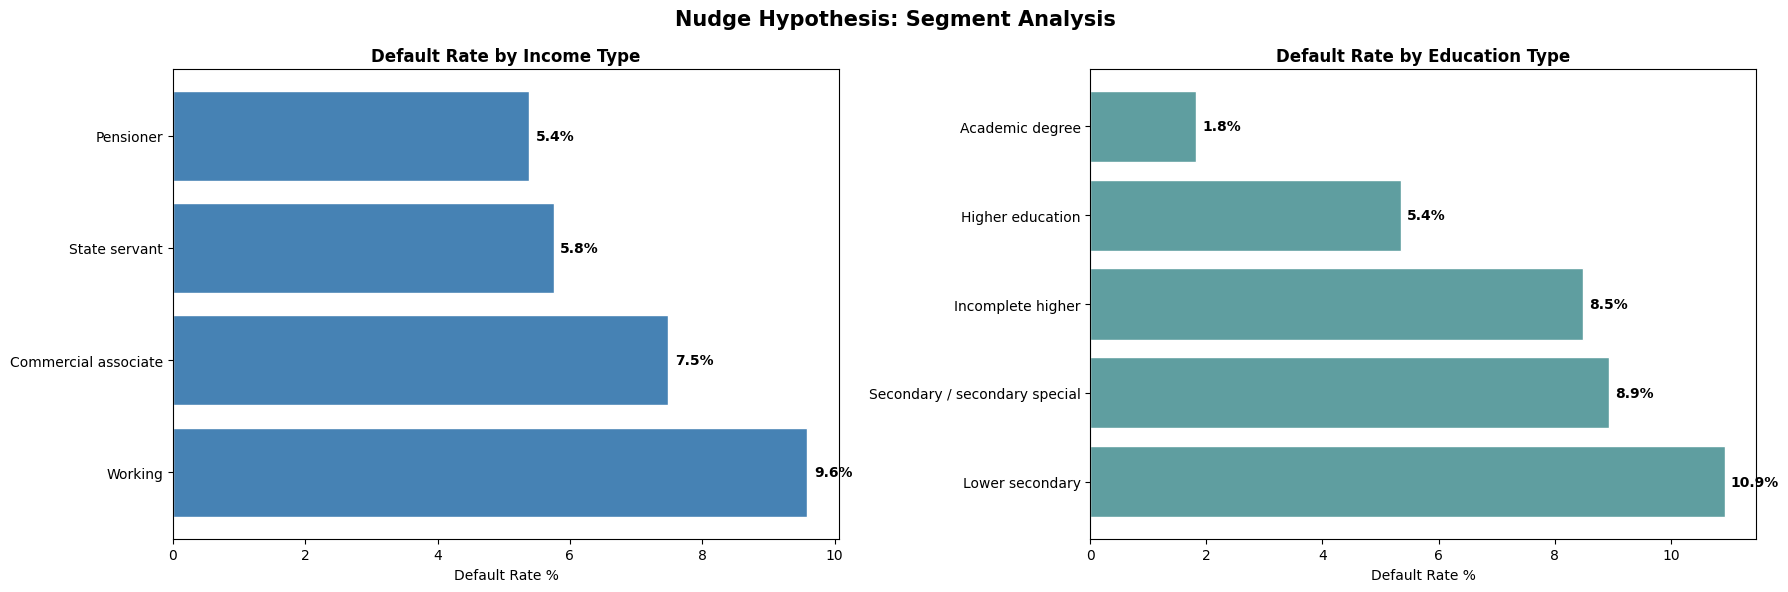

In [23]:
# Nudge Hypothesis Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Filter small segments
income_plot = income_type[income_type['total'] > 100]

# Plot 1 - Income type
axes[0].barh(income_plot['NAME_INCOME_TYPE'],
             income_plot['default_rate'],
             color='steelblue', edgecolor='white')
axes[0].set_title('Default Rate by Income Type', fontweight='bold')
axes[0].set_xlabel('Default Rate %')
for i, v in enumerate(income_plot['default_rate']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontweight='bold')

# Plot 2 - Education type
axes[1].barh(edu_type['NAME_EDUCATION_TYPE'],
             edu_type['default_rate'],
             color='cadetblue', edgecolor='white')
axes[1].set_title('Default Rate by Education Type', fontweight='bold')
axes[1].set_xlabel('Default Rate %')
for i, v in enumerate(edu_type['default_rate']):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.suptitle('Nudge Hypothesis: Segment Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8 -  Data Quality Checks

Two additional data quality validations before modeling.

1. DAYS_EMPLOYED distribution after anomaly fix
2. AMT_GOODS_PRICE missing pattern by contract type

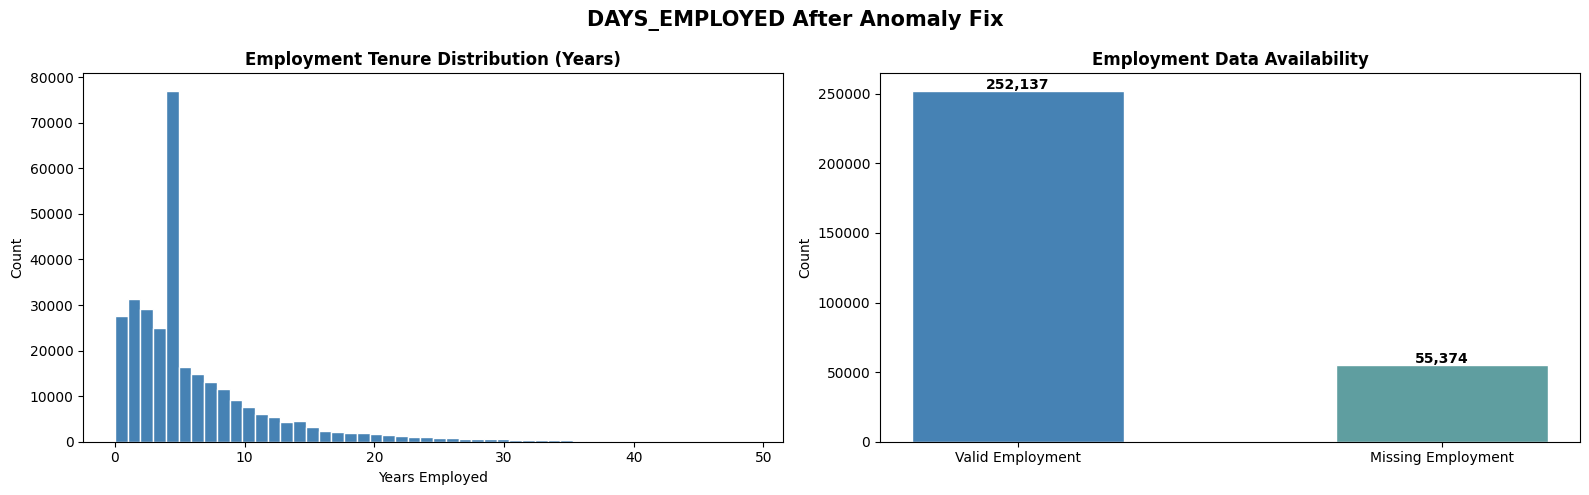

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 - Distribution of valid employment days
valid_employment = df[df['DAYS_EMPLOYED'] < 0]['DAYS_EMPLOYED'].abs() / 365

axes[0].hist(valid_employment, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Employment Tenure Distribution (Years)', fontweight='bold')
axes[0].set_xlabel('Years Employed')
axes[0].set_ylabel('Count')

# Plot 2 - Anomaly flag distribution
anomaly_counts = df['DAYS_EMPLOYED_ANOMALY'].value_counts()
axes[1].bar(['Valid Employment', 'Missing Employment'],
            anomaly_counts.values,
            color=['steelblue', 'cadetblue'],
            edgecolor='white', width=0.5)
axes[1].set_title('Employment Data Availability', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(anomaly_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('DAYS_EMPLOYED After Anomaly Fix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### DAYS_EMPLOYED Finding

After removing the 365,243 anomaly, the true employment tenure 
distribution shows most customers have been employed for less than 
10 years, with a peak around 3 to 5 years. This is a realistic 
distribution for a consumer lending portfolio.

252,137 customers have valid employment data. 55,374 customers 
have missing employment data, preserved as a binary flag for 
modeling purposes.

  CONTRACT_TYPE  MISSING_PCT
     Cash loans          0.0
Revolving loans          0.0


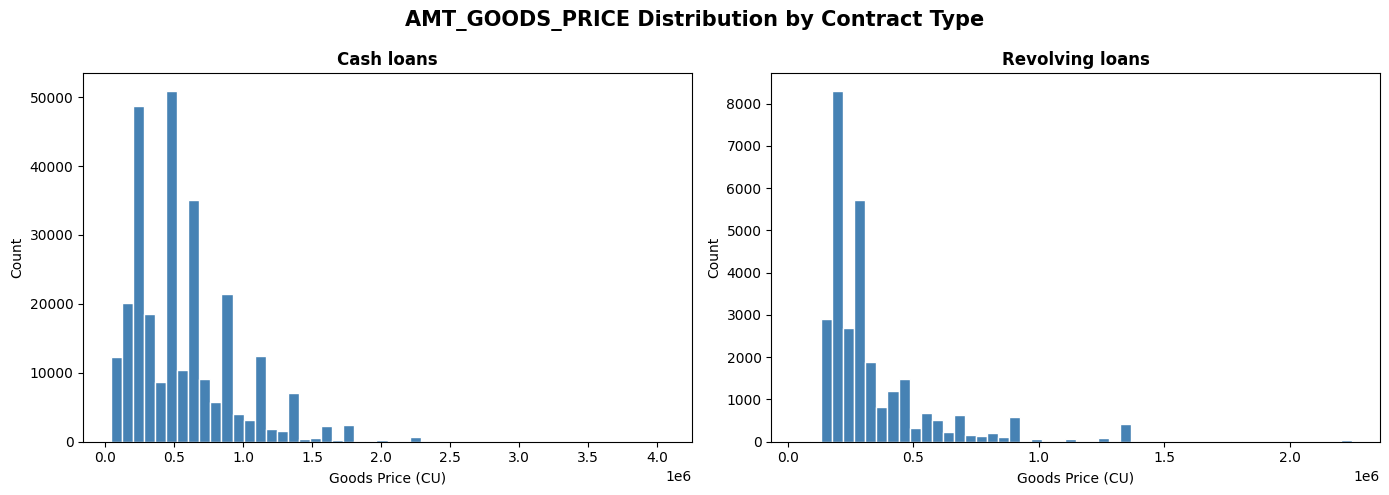

In [25]:
# AMT_GOODS_PRICE Missing by Contract Type
goods_missing = df.groupby('NAME_CONTRACT_TYPE', observed=True).apply(
    lambda x: x['AMT_GOODS_PRICE'].isna().mean() * 100,
    include_groups=False
).reset_index()
goods_missing.columns = ['CONTRACT_TYPE', 'MISSING_PCT']
print(goods_missing.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, contract in enumerate(df['NAME_CONTRACT_TYPE'].unique()):
    subset = df[df['NAME_CONTRACT_TYPE'] == contract]['AMT_GOODS_PRICE']
    axes[i].hist(subset, bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{contract}', fontweight='bold')
    axes[i].set_xlabel('Goods Price (CU)')
    axes[i].set_ylabel('Count')

plt.suptitle('AMT_GOODS_PRICE Distribution by Contract Type', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### AMT_GOODS_PRICE Finding

Cash loans show a wider distribution of goods prices ranging up to 
4 million CU with multiple peaks, suggesting diverse purchase 
categories from small consumer goods to large assets.

Revolving loans are concentrated at lower goods prices, mostly 
below 500,000 CU. This makes sense as revolving credit is typically 
used for smaller recurring purchases rather than large one-time buys.

No missing values remain in either contract type as they were 
handled in our cleaning step.

##  Uplift Readiness Conclusion

In [26]:
print("=" * 45)
print("UPLIFT READINESS CHECK")
print("=" * 45)
print(f"Total customers          : {df.shape[0]:,}")
print(f"Total features           : {df.shape[1]}")
print(f"Missing values           : {df.isnull().sum().sum()}")
print(f"Default rate             : {df['TARGET'].mean()*100:.2f}%")
print(f"Engineered features      : DEBT_TO_INCOME, CREDIT_TO_GOODS, ANNUITY_TO_AGE")
print(f"PSM covariates ready     : EXT_SOURCE_2, EXT_SOURCE_3, DAYS_BIRTH, DEBT_TO_INCOME")
print("=" * 45)

UPLIFT READINESS CHECK
Total customers          : 307,511
Total features           : 88
Missing values           : 0
Default rate             : 8.07%
Engineered features      : DEBT_TO_INCOME, CREDIT_TO_GOODS, ANNUITY_TO_AGE
PSM covariates ready     : EXT_SOURCE_2, EXT_SOURCE_3, DAYS_BIRTH, DEBT_TO_INCOME


## Step 9 - Uplift Readiness Verdict

The data is ready for causal inference and uplift modeling.

**What we confirmed in this EDA:**

- Dataset has 307,511 customers with a clean 8.07% default rate
- All missing values handled through intelligent imputation strategy
- EXT_SOURCE_2 and EXT_SOURCE_3 show strong separation between 
  defaulters and non-defaulters, confirming PSM feasibility
- Engineered features DEBT_TO_INCOME, CREDIT_TO_GOODS, and 
  ANNUITY_TO_AGE all show meaningful relationship with default
- Zero missing values, 87 clean features ready for modeling

**Next Step:** These insights feed directly into Phase 2 where we 
conduct Power Analysis to determine the minimum sample size required 
for a statistically valid experiment.

The data exhibits sufficient feature density and overlap in high-risk 
segments to support a Propensity Score Matching framework for 
Uplift Modeling.

In [30]:
df.drop(columns=['REPAYMENT_BURDEN', 'INCOME_BAND'], inplace=True)

print(f"Dropped: REPAYMENT_BURDEN, INCOME_BAND")
print(f"Final shape: {df.shape}")

Dropped: REPAYMENT_BURDEN, INCOME_BAND
Final shape: (307511, 86)


In [31]:
df.to_csv('../data/processed/cleaned_train.csv', index=False)

print("=" * 45)
print(f"Saved: data/processed/cleaned_train.csv")
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1]}")
print("=" * 45)

Saved: data/processed/cleaned_train.csv
Shape: (307511, 86)
Features: 86


In [32]:
print(f"Total columns: {df.shape[1]}")
print(f"Includes TARGET: yes")
print(f"Features (excluding TARGET): {df.shape[1] - 1}")

Total columns: 86
Includes TARGET: yes
Features (excluding TARGET): 85


In [33]:
df = pd.read_csv('../data/processed/cleaned_train.csv')

print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print("All columns:")
print(list(df.columns))

Shape: (307511, 86)
Missing values: 0

All columns:
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'YEARS_BEGINEXPLUATATION_AVG', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_MODE', 'FLOORSMA